# Preprocessing

In [1]:
from IPython.display import Image

## One-Hot Encoding
- Use _indicator variables_ or _dummy variables_ and convert categorical variables into a numeric format that machine learning models can understand. 
- _E.g.,_ Suppose we have a variable with binary values, including "woman" and "man". 
  - Create an indicator variable, $I_\text{male}$. 
  - Then, $I_\text{female}$ = $ 1 - I_\text{male}$
  - In the $X$-matrix, the concept of the two indicators area collinear. Hence, $I_\text{male} + I_\text{female} = 1$. 
  - One variable of the two should not be included to avoid collinearity. 

## Variable Scaling
### Standardization
$$z = \frac{x - \mu}{\sigma}$$
- Centers data around $0$ (mean = $0$) and a unit standard deviation (standard deviation = $1$).
- Keeps the shape of distribution. 
- Values are not bounded. 
- When to use:
  - Useful for most ML models.
  - When the data has outliers.
  - When data distribution matters. 
- Indicator variables may or may not be scaled. 

### Scaling
- **Min-Max** scaling.
$$ x = \frac{x-\text{min}}{\text{max} - \text{min}}$$
- Limits the data range within $[0,1]$.
- Does not affect indicator variables at all. 
- Rescales values into fixed range. 
- Preserves relative distances. 
- When to use:
  - When you want bounded values.
  - Neural networks.
  - Image data. 

## Text Preprocessing
### TF-IDF
- Stands for **Term Frequency - Inverse Document Frequency**.
- Usually, TF-IDF is computed after _stemming_.  
#### TF
$$\text{TF} =
\begin{cases}
1 + \log(f_{t,d}) & \text{if } f_{t,d} > 0 \\
0 & \text{otherwise}
\end{cases}$$
- $f_{t,d}$ = Number of times a term $t$ appears in document $d$. 
  - _E.g.,_ If a word "_enjoy_" appears only once, then $1+\log{1} = 1$. If appears $100$ times, then $1+\log{100} = 5.6$.
#### IDF
- Rare words are more useful than frequently used words; rare words are given more weight. 
- _Document_ means "text for one observation", such as _one movie review_, _one answer to an open-ended question_. 
$$\text{IDF} = \log{\frac{N}{N_t}}$$
- $N$ = Sample size, $N_t$ = Number of documents containing term $t$ at least once. 
- This function decreases as a function of term frequency. 
- Together with TF, $\text{TF} \cdot \text{IDF}$ creates:
$$((1+\log{f_{t,d}}) \times \log{\frac{N}{N_t}})$$
#### Example

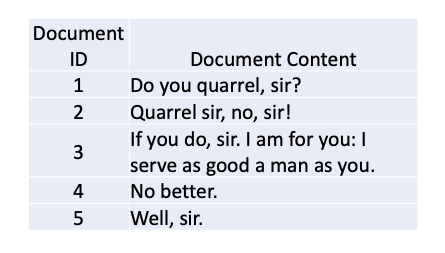

In [2]:
Image("../data/Preprocessing/TF-IDF.png")

- $N = 5$ (5 documents)
- _E.g.,_ Computing the score for "sir":
  - "sir" appears in document 1, 2, 3, 5. 
  - Hence $N_t = 4$.
- **IDF**: $\log{\frac{N}{N_t}} = \log{\frac{5}{4}} = 0.223$. 
- **TF** in the _second document_ for example:
  - "sir" appears twice in the second document. Hence, $1+\log{2} = 1.69$. 
$$\text{TF} \cdot \text{IDF} = 1.69 \times 0.223 = 0.38$$

### Text Similarity
- A value of $0$ indicates that text documents are dissimiliar, and $1$ indicates that the documents are functionally identical.
#### Cosine Similarity
$$\cos(\theta) = \frac{\bar{x}_1 \cdot \bar{x}_2}{\|\bar{x}_1\| \, \|\bar{x}_2\|}$$
- Good representation of similarity between the vector representations of two text documents. 
- Used in nearnest neighbor algorithms, vector space model in information retrieval (e.g., searching for information on the web.)
- $x_1$ and $x_2$ are the two text documents. 

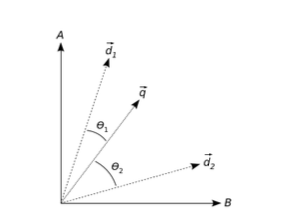

In [5]:
Image("../data/Preprocessing/cosine-similarity.png")

- Assume $\bar{q}$, $\bar{d}_i$ are documents.
- From the diagram, document $q$ is closer to $d_1$ than $d_2$. Return documents that have minimal angle to $q$. 
- Cosine similarity of $1 = \text{Cos}(0) \text{ degrees}$: Vectors heading towards exactly same direction.
- Cosine similarity of $0 = \text{Cos}(90) \text{ degrees}$: Vectors are orthogonal to one another. 

##### Example

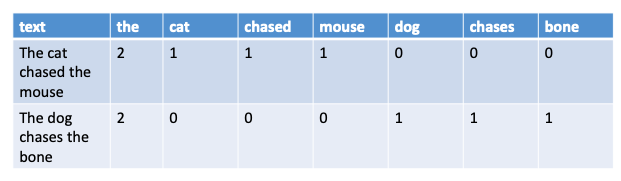

In [6]:
Image("../data/Preprocessing/bag-of-words.png")

- From the image above, we have two vectors:
  - $x_1 = (2, 1, 1, 1, 0, 0, 0)$
  - $x_2 = (2, 0, 0, 0, 1, 1, 1)$
- Compute cosine similarity between two:
  - $\cos(\theta) = \frac{\bar{x}_1 \cdot \bar{x}_2}{\|\bar{x}_1\| \, \|\bar{x}_2\|} = \frac{4}{\sqrt{7} \cdot \sqrt{7}} = 0.57$
    - $\bar{x}_1 \cdot \bar{x}_2 = 4+0+0+0+0+0+0 = 4$
    - $\|\bar{x_1}\| = \sqrt{\sum{x_1^2}} = \sqrt{2^2+1^2+1^2+1^2} = \sqrt{7}$
  - **Interpretation**: 57% of vector directions align, and 57% of words are the same. 
- Document lengths do not matter in cosine similarity. 
- Text order is not preserved in cosine similarity. 

##### Usage
- When you care about topic/content similarity
- Document comparison/retrieval
- High-dimensional sparse data
- Length of documents shouldn't matter

##### Limitation
- Do NOT use when:
  - Word order matters.
  - When meaning of words are important (being able to recognize synonyms).
  - When context matters. ("bank" for either "river bank" or "finance bank" is oblivious.)
  - When sentence-level semantics matter (e.g., subtle meaning differences, tone, sentiment, intent.)